In [83]:
import rasterio
from dist_s1.dist_plot import get_dist_s1_mpl_cmap
import matplotlib.pyplot as plt
import numpy as np
from dem_stitcher.rio_window import read_raster_from_window
from dist_s1_enumerator.mgrs_burst_data import get_mgrs_table
import pandas as pd
from pathlib import Path
from tile_mate import get_raster_from_tiles
from dem_stitcher.rio_tools import reproject_arr_to_match_profile

In [148]:
MGRS_TILE_ID = '22MGB' # '20LMM' '20MMA'


In [149]:
dist_ts_dir = Path('opera_dist_data/')
ts_dir = list(dist_ts_dir.glob(f'*_{MGRS_TILE_ID}/'))[0]
ts_dir

PosixPath('opera_dist_data/builtnewalert__22MGB')

In [150]:
status_files = sorted(list(ts_dir.rglob('OPERA*_GEN-DIST-STATUS.tif')))
status_files[:3]

[PosixPath('opera_dist_data/builtnewalert__22MGB/OPERA_L3_DIST-ALERT-S1_T22MGB_20240105T085030Z_20260205T193502Z_S1A_30_v0.1/OPERA_L3_DIST-ALERT-S1_T22MGB_20240105T085030Z_20260205T193502Z_S1A_30_v0.1_GEN-DIST-STATUS.tif'),
 PosixPath('opera_dist_data/builtnewalert__22MGB/OPERA_L3_DIST-ALERT-S1_T22MGB_20240110T085837Z_20260205T204137Z_S1A_30_v0.1/OPERA_L3_DIST-ALERT-S1_T22MGB_20240110T085837Z_20260205T204137Z_S1A_30_v0.1_GEN-DIST-STATUS.tif'),
 PosixPath('opera_dist_data/builtnewalert__22MGB/OPERA_L3_DIST-ALERT-S1_T22MGB_20240117T085029Z_20260205T200547Z_S1A_30_v0.1/OPERA_L3_DIST-ALERT-S1_T22MGB_20240117T085029Z_20260205T200547Z_S1A_30_v0.1_GEN-DIST-STATUS.tif')]

In [151]:
def get_acq_time(path):
    opera_id = path.stem
    tokens = opera_id.split('_')
    acq_time = pd.to_datetime(tokens[4])
    return acq_time

ts_start = get_acq_time(status_files[0])
ts_end = get_acq_time(status_files[-1])
ts_start, ts_end


(Timestamp('2024-01-05 08:50:30+0000', tz='UTC'),
 Timestamp('2024-12-30 08:50:25+0000', tz='UTC'))

In [152]:
COMP_DIR = Path(f'comparison_dir / {MGRS_TILE_ID}')
COMP_DIR.mkdir(exist_ok=True, parents=True)

In [154]:
RADD_PATH = list(Path('.').glob(f'radd_data/RADD*{MGRS_TILE_ID}*.tif'))[0]
RADD_PATH

PosixPath('radd_data/RADD_FullStack_2026-02-15_22MGB.tif')

In [155]:
AUX_DATA = Path('aux_data')
AUX_DATA.mkdir(exist_ok=True)

In [156]:
df_mgrs = get_mgrs_table()
df_mgrs_tile = df_mgrs[df_mgrs['mgrs_tile_id'] == MGRS_TILE_ID]
mgrs_bounds = df_mgrs_tile.total_bounds.tolist()
mgrs_bounds 

[-49.2013034858328, -3.70569975276562, -48.2115792326372, -2.71094955181137]

In [ ]:
LANDCOVER_PATH = AUX_DATA / f'{MGRS_TILE_ID}_landcover_umd_lc.tif'
if not LANDCOVER_PATH.exists():
    X_glad, p_glad = get_raster_from_tiles(mgrs_bounds, 'glad_landcover', year=2020)
    with rasterio.open(LANDCOVER_PATH, 'w', **p_glad) as dst:
        dst.write(X_glad)
else:
    with rasterio.open(LANDCOVER_PATH) as src:
        p_glad = src.profile
        X_glad = src.read()

Reading tile imagery:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
HANSEN_LOSS_YEAR = AUX_DATA / f'{MGRS_TILE_ID}_hansen_lossyear.tif'
if not HANSEN_LOSS_YEAR.exists():
    X_ly, p_ly = get_raster_from_tiles(mgrs_bounds, 'hansen_lossyear')
    with rasterio.open(HANSEN_LOSS_YEAR, 'w', **p_ly) as dst:
        dst.write(X_ly)
else:
    with rasterio.open(HANSEN_LOSS_YEAR) as src:
        p_ly = src.profile
        X_ly = src.read()

Reading tile imagery: 100%|██████████| 1/1 [00:01<00:00,  1.58s/it]


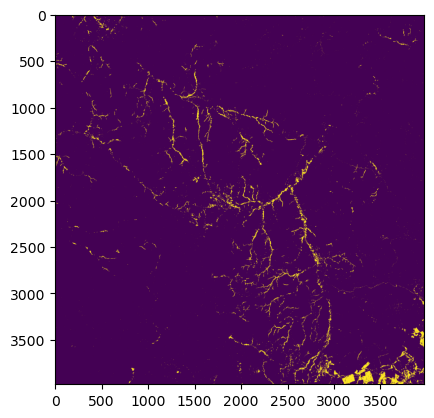

In [ ]:
ly_mask = (X_ly[0, ...] > 0) & (X_ly[0, ...] <= 18).astype(np.uint8)
plt.imshow(ly_mask)

In [ ]:
# LANDCOVER_PATH = Path(f'{MGRS_TILE_ID}_landcover_esa_2021.tif')
# if not LANDCOVER_PATH.exists():
#     X_esa, p_esa = get_raster_from_tiles(mgrs_bounds, 'esa_world_cover_2021')
#     with rasterio.open(LANDCOVER_PATH, 'w', **p_esa) as dst:
#         dst.write(X_esa)
# else:
#     with rasterio.open(LANDCOVER_PATH) as src:
#         p_esa = src.profile
#         X_esa = src.read(1)

In [ ]:
terra_firma_dense_short_veg = list(range(19, 25))
terra_firma_tree_cover = list(range(25, 49))
wetland_tree_cover = list(range(125, 149))

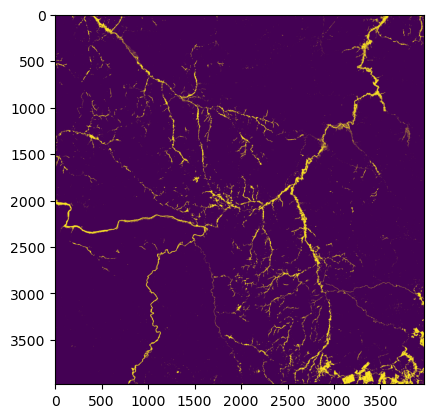

In [ ]:
ly_mask_r, _ = reproject_arr_to_match_profile(ly_mask, p_ly, p_glad,  resampling='nearest')
ly_mask_r = ly_mask_r[0, ...].astype(bool)
X_glad_mask = ~(np.isin(X_glad[0, ...],  terra_firma_tree_cover))
X_mask = (X_glad_mask | ly_mask_r).astype(np.uint8)
plt.imshow(X_mask)

In [ ]:
MASK_PATH = AUX_DATA / f'mask_{MGRS_TILE_ID}.tif'

In [ ]:
with rasterio.open(MASK_PATH, 'w', **p_glad) as dst:
    dst.write(X_mask, 1)


In [ ]:
X_radd, p_radd = read_raster_from_window(RADD_PATH, mgrs_bounds)

In [ ]:
radd_alert = X_radd[0, ...]
radd_date = X_radd[1, ...]

In [ ]:
alert_f = np.zeros(radd_alert.shape, dtype=np.uint8)
alert_f[radd_alert == 3] = 6
alert_f[radd_alert == 2] = 3

dist_cmap, dist_norm = get_dist_s1_mpl_cmap()


In [ ]:
X_mask_radd, _ = reproject_arr_to_match_profile(X_mask, p_glad, p_radd, resampling='nearest')
X_mask_radd = X_mask_radd[0, ...]


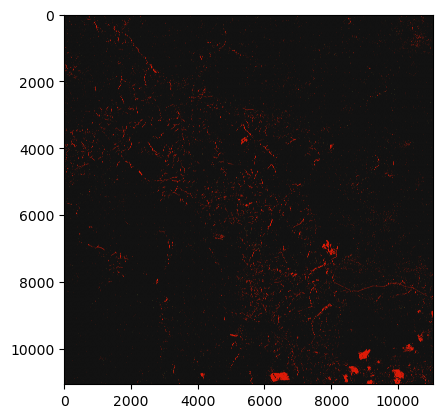

In [ ]:
plt.imshow(alert_f, norm=dist_norm, cmap=dist_cmap)


In [ ]:
radd_date_year = radd_date // 1000
radd_day_of_year = radd_date % 1000

In [ ]:
np.max(radd_date_year)

np.int16(26)

In [ ]:
ts_start.year

2025

In [ ]:
assert (ts_start.year == ts_end.year)
radd_year_filter = (radd_date_year == int(str(ts_start.year)[-2:]))

In [ ]:
day_start = (ts_start - pd.Timestamp(f'{ts_start.year}-01-01', tz='UTC')).days
day_end = (ts_end - pd.Timestamp(f'{ts_start.year}-01-01', tz='UTC')).days

radd_filter = (radd_day_of_year >= day_start) & (radd_day_of_year <= day_end) & radd_year_filter

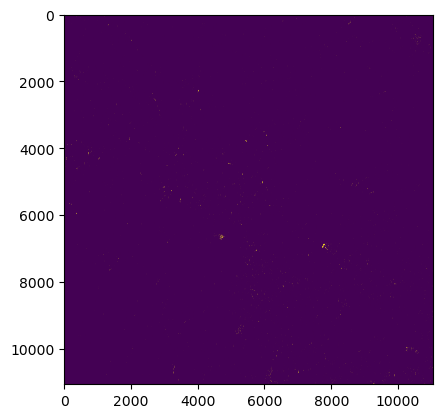

In [ ]:
plt.imshow(radd_filter)

In [ ]:
radd_alerts_2024 = np.zeros(radd_alert.shape, dtype=np.uint8)
radd_alerts_2024[(radd_date_year==24)] = 6

# All confirmed

In [ ]:
def open_one_arr(path):
    with rasterio.open(path) as src:
        return src.read(1)

status_arrs = list(map(open_one_arr, status_files))
status_arrs_stacked = np.stack(status_arrs, axis=0)

with rasterio.open(status_files[0]) as src:
    p_dist = src.profile
    cmap_dist = src.colormap(1)


In [ ]:
confirmed_low_mask = (status_arrs_stacked == 3).any(axis=0)
confirmed_high_mask = (status_arrs_stacked == 6).any(axis=0)

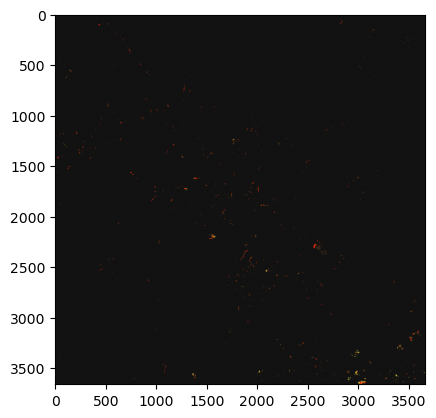

In [ ]:
status_agg = np.zeros(status_arrs_stacked.shape[1:], dtype=np.uint8)
status_agg[confirmed_low_mask] = 3
status_agg[confirmed_high_mask] = 6
plt.imshow(status_agg, cmap=dist_cmap, norm=dist_norm)


In [ ]:
X_mask_dist_s1, _ = reproject_arr_to_match_profile(X_mask, p_glad, p_dist, resampling='nearest')
X_mask_dist_s1 = X_mask_dist_s1[0, ...].astype(bool)

In [ ]:
with rasterio.open(COMP_DIR / f'{MGRS_TILE_ID}_status_agg_all.tif', 'w', **p_dist) as dst:
    dst.write(status_agg, 1)
    dst.write_colormap(1, cmap_dist)

status_agg_masked = status_agg.copy()

status_agg_masked[X_mask_dist_s1] = 0
with rasterio.open(COMP_DIR / f'{MGRS_TILE_ID}_status_agg_masked.tif', 'w', **p_dist) as dst:
    dst.write(status_agg_masked, 1)
    dst.write_colormap(1, cmap_dist)

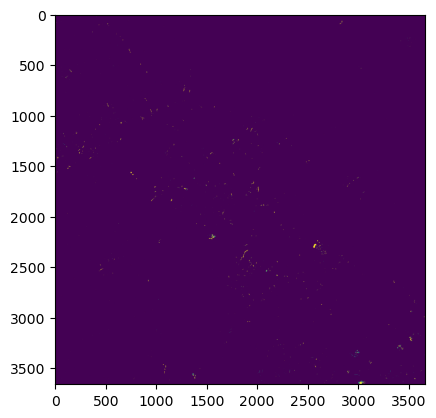

In [ ]:
plt.imshow(status_agg_masked)

In [ ]:
p_2024 = p_radd.copy()
p_2024['count'] = 1
p_2024['dtype'] = 'uint8'
with rasterio.open(COMP_DIR / 'radd_2024_alerts.tif', 'w', **p_2024) as ds:
    ds.write(radd_alerts_2024, 1)
    ds.write_colormap(1, cmap_dist)

radd_alerts_2024_masked = radd_alerts_2024.copy()
radd_alerts_2024_masked[X_mask] = 0
with rasterio.open(COMP_DIR / 'radd_2024_alerts_masked.tif', 'w', **p_2024) as ds:
    ds.write(radd_alerts_2024_masked, 1)
    ds.write_colormap(1, cmap_dist)